# Data Loading & Date Parsing

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Load Data

In [2]:
df = pd.read_csv("../data/tanzania.csv")  # replace with your file
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


## Add Country Column

In [3]:
df["Country"] = "Tanzania"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


## Convert the YEAR and DOY columns into datetime column

In [4]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df.drop(columns=["YEAR", "DOY"], inplace=True)
df.rename(columns={"date": "YEAR"}, inplace=True)
df.tail()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR
4103,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27
4104,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28
4105,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29
4106,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30
4107,28.14,31.55,26.06,5.49,0.83,74.46,1.35,1.90,100.47,17.56,Tanzania,2026-03-31


## Extract Month

In [5]:
df["month"] = df["YEAR"].dt.month
df.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,YEAR,month
0,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


# Summary Statistics & Missing-Value Report

## Replace all occurrences of -999 with np.nan

In [6]:
df = df.replace(-999, np.nan)

## drop any duplicate rows

In [7]:
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [T2M, T2M_MAX, T2M_MIN, T2M_RANGE, PRECTOTCORR, RH2M, WS2M, WS2M_MAX, PS, QV2M, Country, YEAR, month]
Index: []


In [8]:
df.describe(include="number")

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,6.423564
std,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,3.477046
min,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,1.000000
25%,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,3.000000
50%,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,6.000000
75%,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,9.000000
max,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,12.000000


## Summary Statistics Interpretation

The dataset reflects a **warm and humid climate** with **very stable temperatures** and variability driven much more by rainfall than temperature.

- **Mean temperature (~26.8°C)** indicates consistently warm conditions year-round, while the low standard deviation (~1.33°C) suggests very little seasonal temperature fluctuation.

- **Daily temperature range (~4.1°C)** is relatively small, showing limited day–night temperature variation, which is typical of **humid tropical climates** where moisture moderates temperature swings.

- **Precipitation is strongly right-skewed**, with a low median (~0.64 mm/day) compared to the mean (~3.74 mm/day) and occasional extreme rainfall events reaching **122.65 mm/day**, indicating many low-rainfall days interrupted by intense storms.

- **Relative humidity is consistently high (~77%)**, with values reaching above 90%, reinforcing a **moist atmospheric regime** that likely supports seasonal rainfall patterns.

- **Wind speeds are generally moderate** (mean ~4.1 m/s), with occasional stronger events (up to 8.4 m/s), suggesting mostly stable but sometimes active surface wind conditions.

- **Surface pressure remains highly stable** (mean ~100.8 kPa, very low variability), indicating consistent atmospheric conditions with minimal pressure-driven disturbance.

- **Specific humidity (QV2M)** is relatively high (~16.9 g/kg), further confirming abundant atmospheric moisture.

### Overall Interpretation

Overall, the dataset appears characteristic of a **tropical humid climate**, where:

- **Temperature variability is low**
- **Rainfall variability is high**
- **Humidity remains persistently elevated**

Climate variability in this dataset appears to be driven much more by **precipitation dynamics and moisture patterns** than by changes in temperature.

## missing values per column

In [9]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
YEAR           0
month          0
dtype: int64

In [10]:
missing_percent = (df.isna().sum() / len(df)) * 100
high_missing = missing_percent[missing_percent > 5]
high_missing

Series([], dtype: float64)

Interpretation of Missing Data (>5%)

Columns with **more than 5% missing values** may indicate issues in **data collection, sensor failure, or incomplete records**.

Key implications:
- Missing **precipitation data** could bias rainfall analysis and lead to incorrect conclusions about wet and dry seasons.
- Missing **temperature values** may distort seasonal trends and affect climate pattern interpretation.
- Missing **humidity or wind data** can reduce the reliability of atmospheric condition analysis.

Recommended handling:
- **Imputation** (mean, median, interpolation) for moderate missingness
- **Removal** if the column is not critical or has excessive missing data
- **Careful evaluation** before deciding, based on the importance of the variable in analysis or modeling

Overall, columns with high missingness should be treated carefully to avoid introducing bias into the analysis.

# Outlier Detection & Basic Cleaning

## Compute Z-scores

In [11]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
# Compute Z-scores
z_scores = df[cols].apply(stats.zscore)
z_scores

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,0.571659,0.260036,0.769820,0.437306,0.757801,0.542271,0.675588
1,0.594297,0.602855,0.574413,-0.042516,0.493495,0.353533,0.074701
2,0.503746,0.092274,0.789361,0.428559,0.570420,0.759318,0.659126
3,0.360374,0.004746,0.600467,1.540646,0.917568,0.731008,0.724976
4,-0.092378,-0.972651,0.522304,1.885517,1.156232,0.060990,0.650894
...,...,...,...,...,...,...,...
4103,0.624480,1.084260,0.405060,-0.097496,0.069422,-2.392594,-2.295922
4104,0.533930,1.507312,-0.129054,-0.261185,0.116760,-2.590769,-2.798033
4105,0.707485,1.492724,0.190112,-0.307418,0.043780,-2.430342,-2.616944
4106,0.775398,1.551077,0.177084,-0.352401,-0.123876,-2.326536,-2.501705


### Flag rows where |Z| > 3

In [12]:
# Flag rows where |Z| > 3 in ANY column
outlier_mask = (z_scores.abs() > 3).any(axis=1)
outlier_rows = df[outlier_mask]

# outlier_rows.to_csv("../data/outliers.csv", index=False)

### Count how many rows contain at least one outlier

In [13]:
outlier_counts = (z_scores.abs() > 3).sum()
outlier_counts

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64

In [14]:
# Summary report
print("*** Z-Score Outlier Report ***\n")
print("Outliers per column:")
print(outlier_counts.to_string())
print(f"\nTotal rows flagged (outlier in ANY column): {outlier_mask.sum()}")
print(f"Percentage of dataset flagged: {outlier_mask.sum() / len(df) * 100:.2f}%")
print(f"\nFlagged rows preview:")
print(outlier_rows[cols].head(10))

*** Z-Score Outlier Report ***

Outliers per column:
T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4

Total rows flagged (outlier in ANY column): 97
Percentage of dataset flagged: 2.36%

Flagged rows preview:
       T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  WS2M  WS2M_MAX
78   27.55    28.76    26.78        27.78  85.90  3.93      4.94
112  26.48    27.26    25.85        29.37  88.49  4.78      6.94
123  27.09    28.37    26.18        45.31  86.72  4.36      5.57
124  26.60    28.50    24.91        71.10  87.49  4.17      5.42
126  26.75    28.04    25.98        48.50  88.52  4.61      5.52
127  26.41    27.55    25.57        37.08  86.39  5.42      6.34
214  25.54    27.84    24.19         0.27  67.38  7.31      8.25
256  26.08    28.66    24.56         0.70  67.26  7.29      8.55
478  27.65    29.03    26.75        30.16  84.50  3.88      4.76
481  27.43    29.42    26.02        27.85  83.85  5.39      6.8

### Outlier Handling Decision (Integrated Analysis)

The outlier analysis shows that **97 rows (2.36%)** of the dataset are flagged as containing at least one outlier. This is a **very small proportion of the data**, indicating that flagged observations likely represent **natural climate extremes rather than widespread data quality issues**.

#### 1. Nature of Outliers by Variable

- **PRECTOTCORR (81 outliers)**  
  Most outliers are concentrated in precipitation. Given the strong right-skew in rainfall distribution (median near zero, maximum 66.49 mm/day), these are consistent with **episodic heavy rainfall events**, not data errors.

- **Temperature variables (T2M, T2M_MAX, T2M_MIN)**  
  Very few temperature outliers were detected (1–4), suggesting highly stable temperature behavior. These likely represent **rare but plausible hot or cool events**, not anomalies.

- **RH2M (2 outliers)**  
  Very few humidity outliers appear despite a wide humidity range (4.69%–87.16%), indicating humidity is generally well-behaved with only occasional extreme dry or moist conditions.

- **Wind variables (WS2M, WS2M_MAX)**  
  A small number of outliers (8 and 4) suggest mostly stable wind conditions with occasional stronger wind episodes.

#### 2. Contextual Interpretation

- The dataset reflects a **hot, predominantly dry climate where variability is driven primarily by rainfall extremes rather than temperature fluctuations**.
- Rainfall outliers align with **rare storm or rainy-season events**, which are meaningful climate signals rather than noise.
- Wind outliers likely correspond to occasional high-wind events, while temperature outliers reflect natural extremes.
- The preview of flagged rows shows many outliers occur during **high humidity + high rainfall conditions**, suggesting clustered meteorological events rather than random anomalies.

Removing these values would reduce the dataset’s ability to represent **extreme precipitation events and climate variability**, which are often the most important signals in environmental analysis.

#### 3. Decision

- **Do NOT remove outliers globally.**

- Instead:
  - Retain all observations for **climate and seasonal analysis**
  - Apply **log transformation** (e.g., `log1p`) to PRECTOTCORR for modeling or distribution analysis
  - Treat flagged rainfall events as **meaningful extremes**, not noise to be discarded

## Handle remaining missing values

In [15]:
# Step 1: Define threshold (30% missing)
threshold = int(df.shape[1] * 0.3)

# Step 2: Drop rows with too many missing values
df_cleaned = df[df.isnull().sum(axis=1) <= threshold]

# Step 3: Forward-fill remaining missing values
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


C:\Users\bemnet\AppData\Local\Temp\ipykernel_33908\3189414256.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_cleaned[weather_cols] = df_cleaned[weather_cols].fillna(method="ffill")


## Export the cleaned DataFrame

In [17]:
df_cleaned[weather_cols].to_csv("../data/tanzania_clean.csv", index=False)

# Time Series Analysis

In [21]:
df["date"] = pd.to_datetime(df["YEAR"])
# Create Year-Month column
df["year_month"] = df["date"].dt.to_period("M")
# Compute monthly average T2M
monthly_avg = df.groupby("year_month")["T2M"].mean().reset_index()
# Convert back to timestamp for plotting
monthly_avg["year_month"] = monthly_avg["year_month"].dt.to_timestamp()
# Find warmest and coolest months
warmest = monthly_avg.loc[monthly_avg["T2M"].idxmax()]
coolest = monthly_avg.loc[monthly_avg["T2M"].idxmin()]


##  monthly average T2M

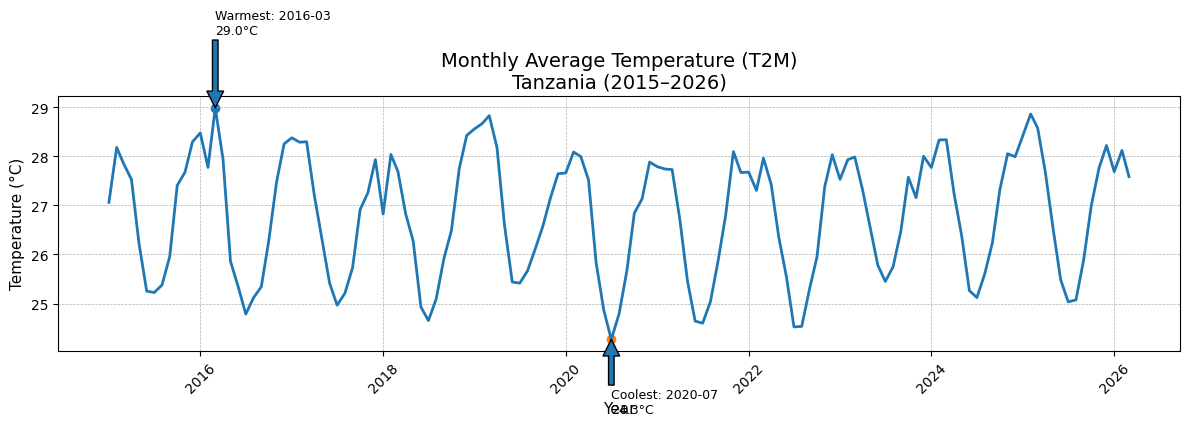

In [22]:

plt.figure(figsize=(12, 5))  # wider for time series

# Line plot
plt.plot(monthly_avg["year_month"], monthly_avg["T2M"], linewidth=2)

# Highlight warmest & coolest points
plt.scatter(warmest["year_month"], warmest["T2M"])
plt.scatter(coolest["year_month"], coolest["T2M"])

# Annotate warmest
plt.annotate(
    f"Warmest: {warmest['year_month'].strftime('%Y-%m')}\n{warmest['T2M']:.1f}°C",
    xy=(warmest["year_month"], warmest["T2M"]),
    xytext=(warmest["year_month"], warmest["T2M"] + 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Annotate coolest
plt.annotate(
    f"Coolest: {coolest['year_month'].strftime('%Y-%m')}\n{coolest['T2M']:.1f}°C",
    xy=(coolest["year_month"], coolest["T2M"]),
    xytext=(coolest["year_month"], coolest["T2M"] - 1.5),
    arrowprops=dict(),
    fontsize=9
)

# Titles and labels
plt.title("Monthly Average Temperature (T2M)\nTanzania (2015–2026)", fontsize=14)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Temperature (°C)", fontsize=11)

# Grid for readability
plt.grid(True, linestyle="--", linewidth=0.5)

# Improve x-axis ticks (less crowded)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## monthly total PRECTOTCORR

In [24]:
monthly_rain = df.groupby("year_month")["PRECTOTCORR"].sum().reset_index()

monthly_rain["year_month"] = monthly_rain["year_month"].dt.to_timestamp()
peak_months = monthly_rain.nlargest(2, "PRECTOTCORR")

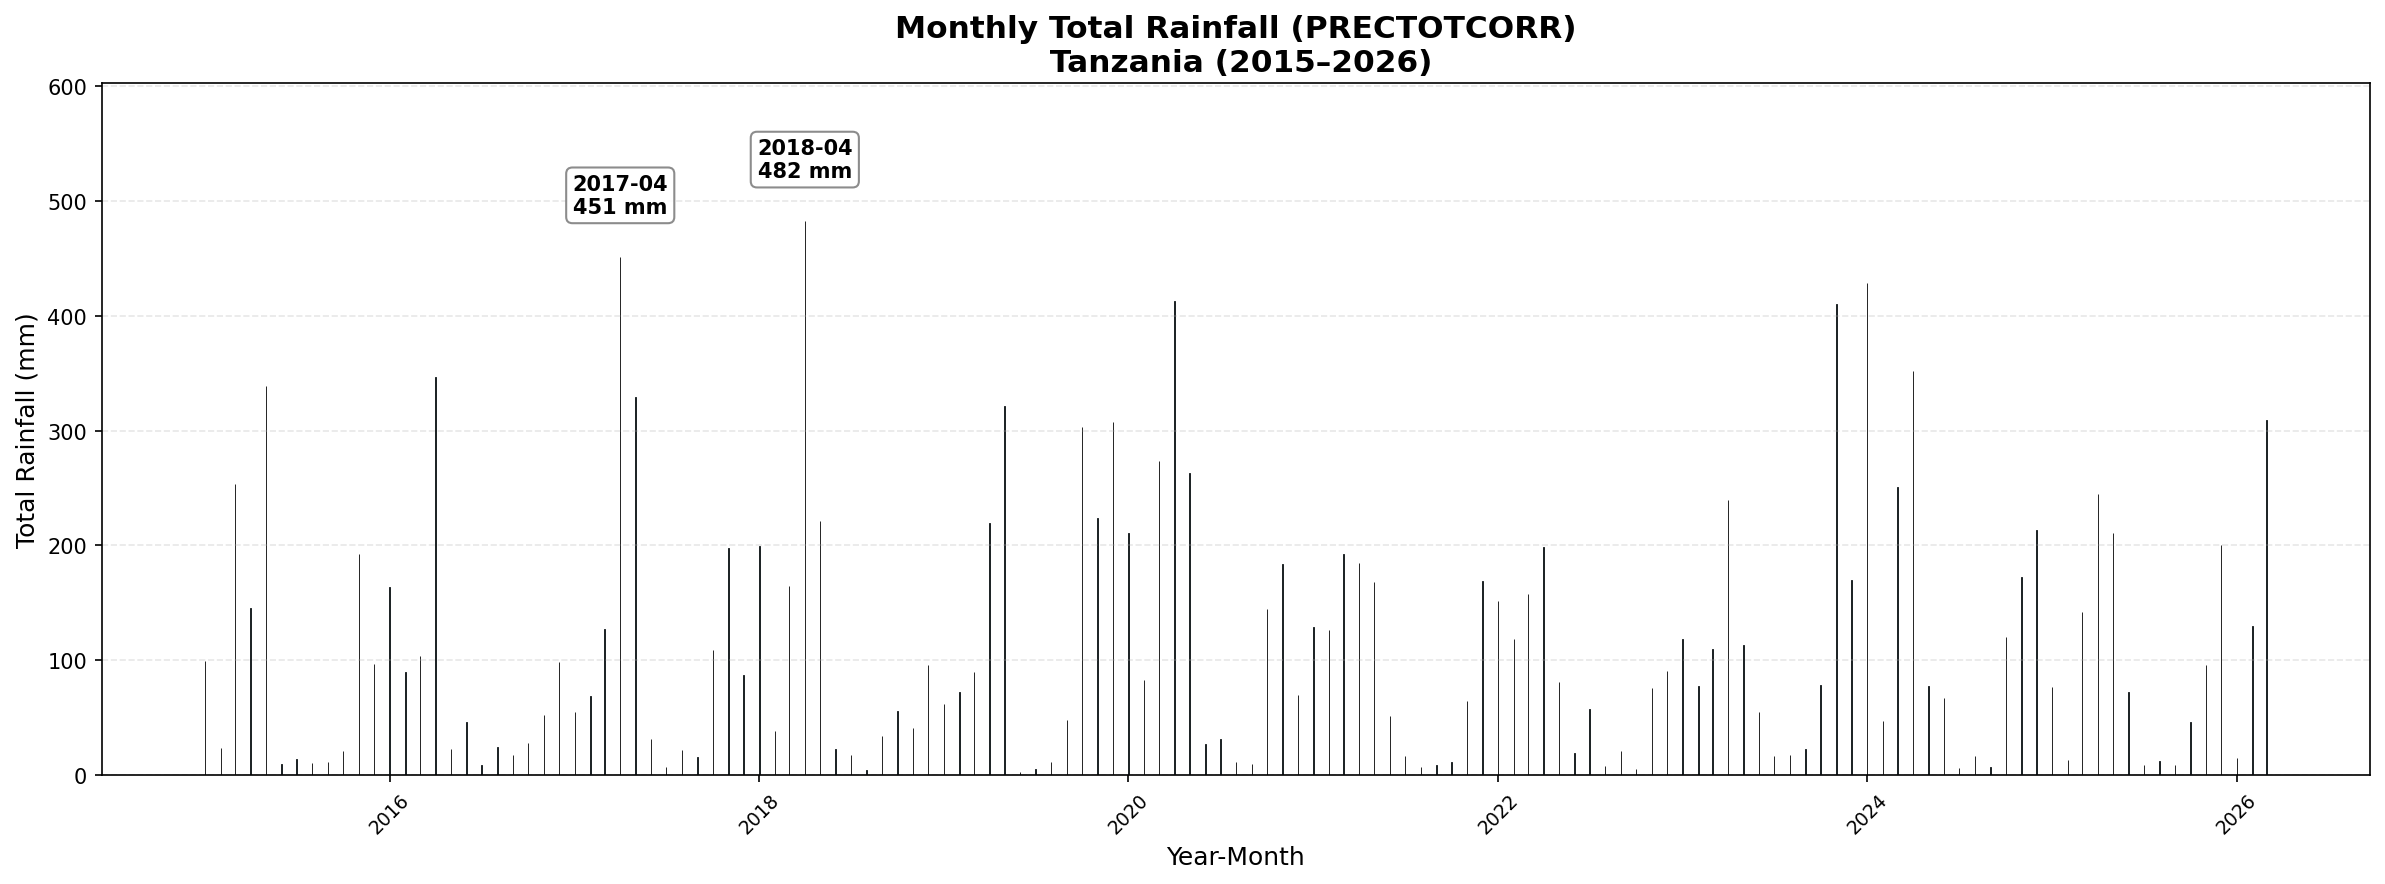

In [25]:
plt.figure(figsize=(16, 6), dpi=150)

monthly_rain_sorted = monthly_rain.sort_values("year_month")

# Base bar plot
plt.bar(
    monthly_rain_sorted["year_month"],
    monthly_rain_sorted["PRECTOTCORR"],
    color="skyblue",
    edgecolor="black",
    linewidth=0.4
)

# Peak months
peak_months = monthly_rain_sorted.nlargest(2, "PRECTOTCORR")

# Dynamic y-limit padding (IMPORTANT FIX)
y_max = monthly_rain_sorted["PRECTOTCORR"].max()
plt.ylim(0, y_max * 1.25)

# Place annotations HIGH ABOVE bars (fixed position logic)
for _, row in peak_months.iterrows():
    plt.text(
        row["year_month"],
        row["PRECTOTCORR"] + (y_max * 0.08),  # always above bar
        f"{row['year_month'].strftime('%Y-%m')}\n{row['PRECTOTCORR']:.0f} mm",
        ha="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9)
    )

# Styling
plt.title("Monthly Total Rainfall (PRECTOTCORR)\n Tanzania (2015–2026)",
          fontsize=15, fontweight="bold")

plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Rainfall (mm)", fontsize=12)

plt.xticks(rotation=45, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation & Relationship Analysis

## Heatmap of correlations

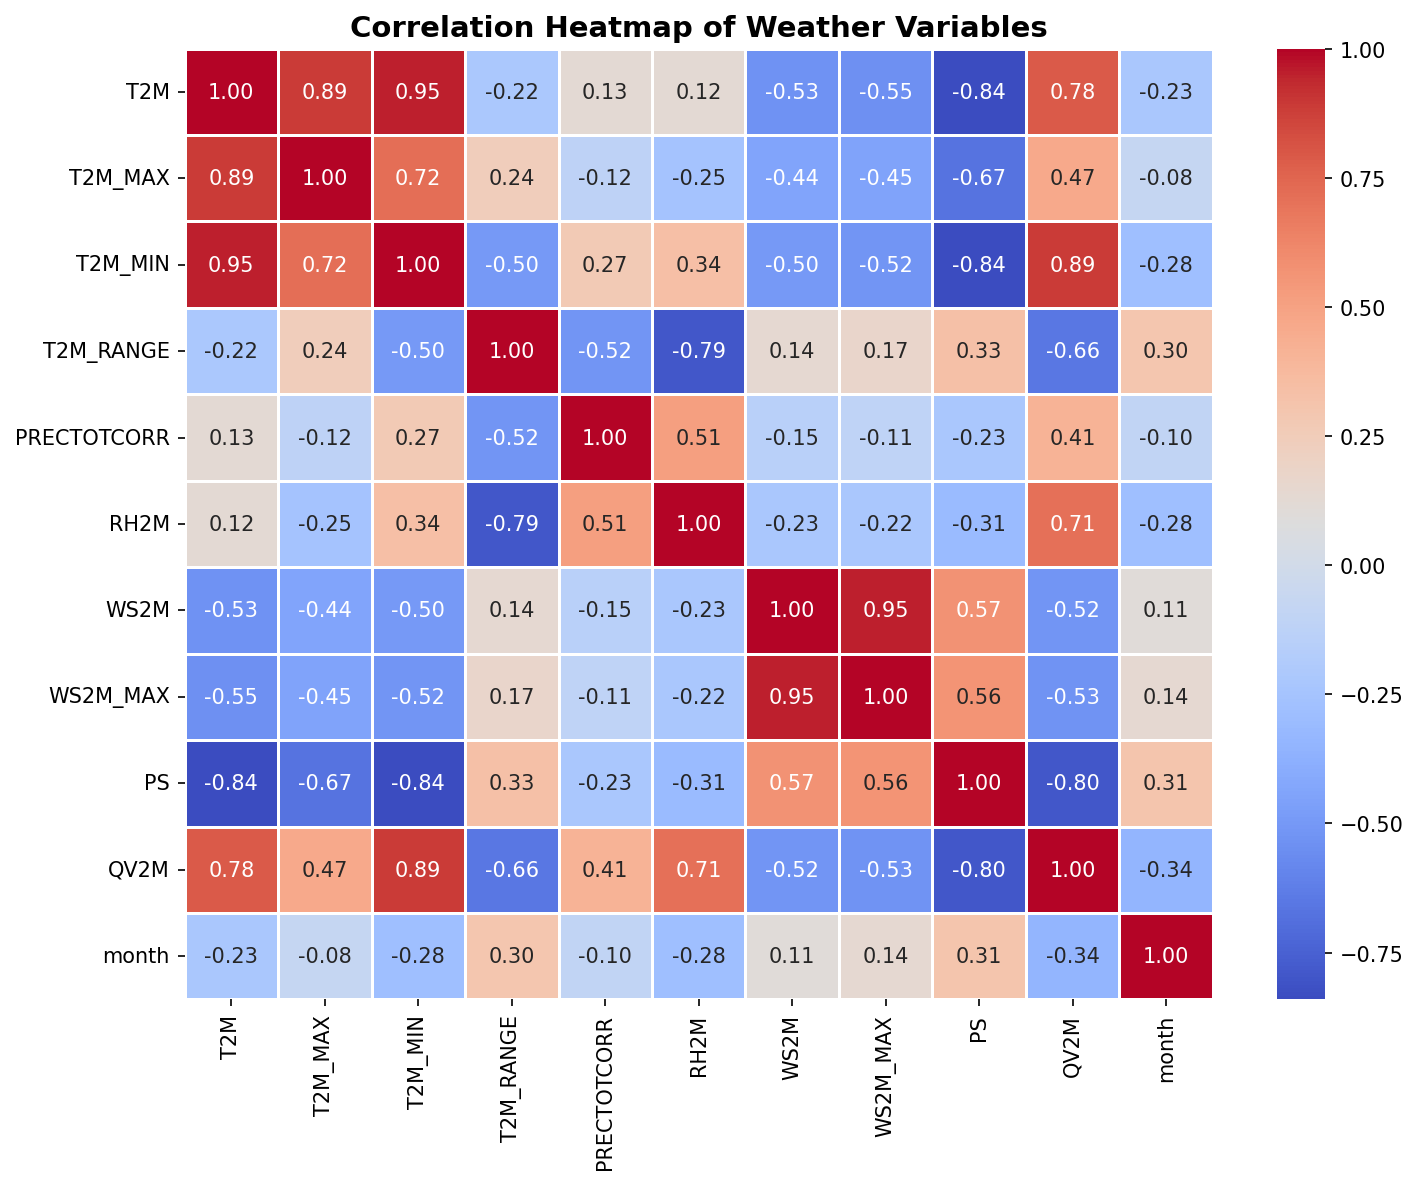

In [26]:
# Select only numeric columns and compute correlation matrix
# This measures how strongly each variable is linearly related to others
corr = df.select_dtypes(include="number").corr()
# Set figure size and resolution for better readability
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap of correlation matrix
sns.heatmap(
    corr,              # correlation values
    annot=True,        # show numerical values inside cells
    fmt=".2f",         # format numbers to 2 decimal places
    cmap="coolwarm",   # color scheme (blue = negative, red = positive)
    linewidths=0.5     # adds spacing between cells for clarity
)

# Add title to the plot
plt.title("Correlation Heatmap of Weather Variables", fontsize=14, fontweight="bold")

# Improve layout so labels don’t overlap
plt.tight_layout()

# Display the plot
plt.show()

## T2M vs RH2M (Temperature vs Humidity)

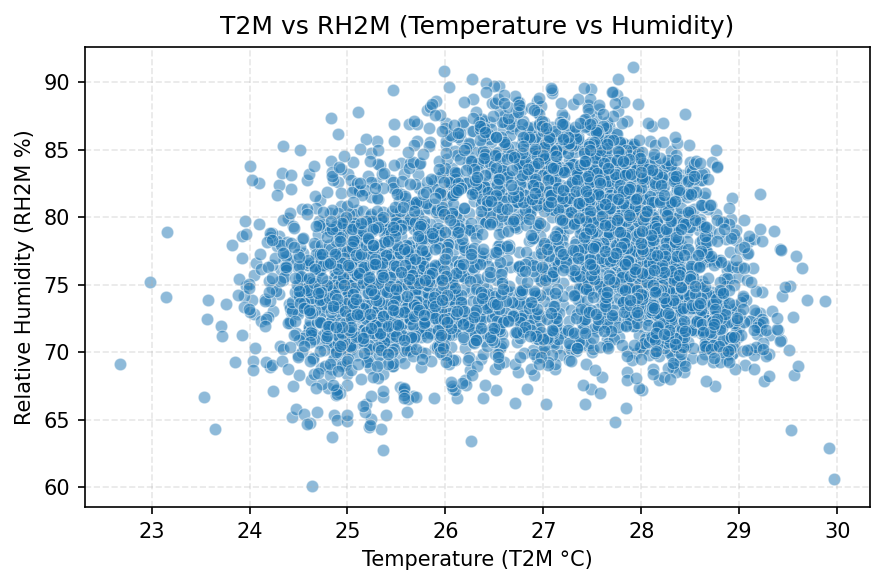

In [27]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    alpha=0.5
)

plt.title("T2M vs RH2M (Temperature vs Humidity)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)

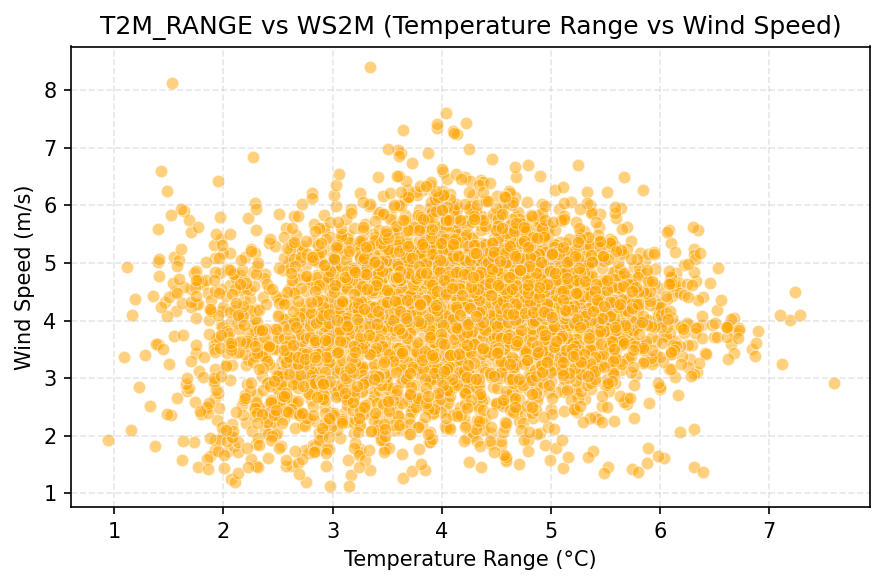

In [29]:
plt.figure(figsize=(6,4), dpi=150)

sns.scatterplot(
    data=df,
    x="T2M_RANGE",
    y="WS2M",
    alpha=0.5,
    color="orange"
)

plt.title("T2M_RANGE vs WS2M (Temperature Range vs Wind Speed)")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Scatter Plot Insights

- **T2M vs RH2M:**  
  The relationship between temperature and relative humidity appears **weakly nonlinear and clustered**, rather than strongly linear.  
  Humidity remains generally high (roughly 70–90%) across the temperature range, with the densest concentration occurring around **26–28°C** and **75–85% humidity**, suggesting persistently moist atmospheric conditions.  
  A slight arch-shaped pattern suggests humidity peaks around moderate temperatures and declines slightly at the warmest end.  
  → This indicates **stable warm-moist conditions**, with humidity variability only moderately influenced by temperature.

- **T2M_RANGE vs WS2M:**  
  A **weak positive-to-neutral relationship** is observed, with substantial dispersion and no strong linear trend.  
  Most observations cluster around temperature ranges of **3–5.5°C** and wind speeds of **3–5 m/s**, suggesting moderate winds dominate across most diurnal temperature conditions.  
  Some higher wind speeds occur at mid-range temperature variability, but no strong evidence suggests wind directly drives large changes in temperature range.  
  → Wind appears to have **limited direct control** over daily temperature-range variability, with only a modest association.

### Overall Insight

> The climate appears characterized by **persistently warm and humid conditions**, with relatively stable temperature–humidity coupling and limited evidence that wind strongly influences daily temperature variability. Moisture conditions appear more structured and climatologically important than wind-driven effects.

## Distribution Analysis

### Histogram of PRECTOTCORR

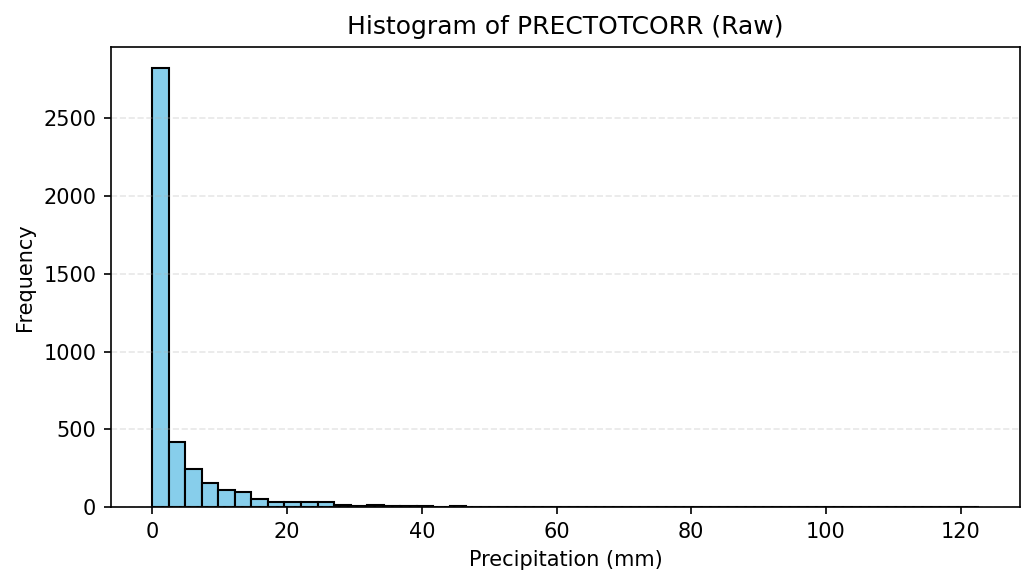

In [30]:
plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR"], bins=50, color="skyblue", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Raw)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Log-Transformed Histogram

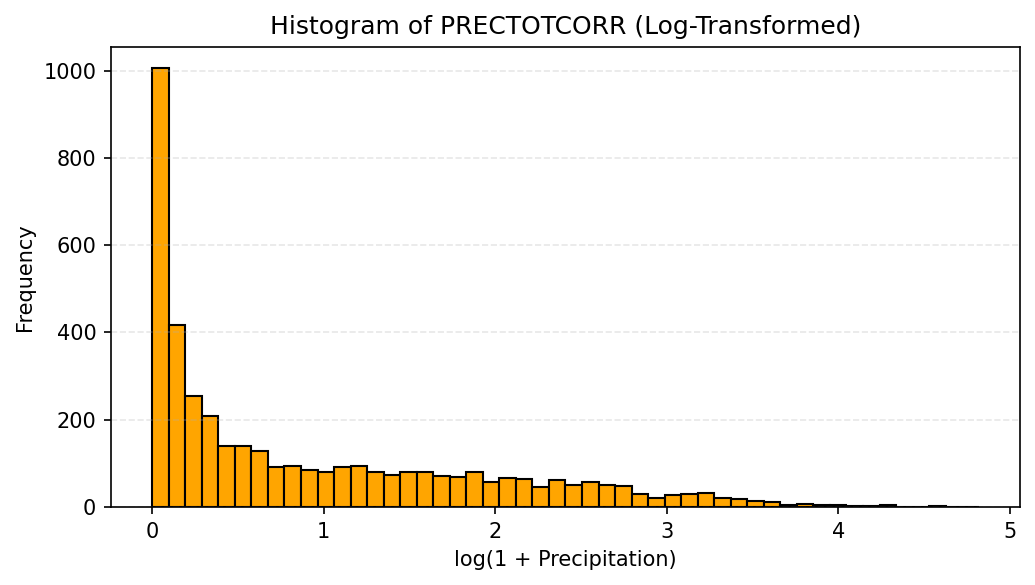

In [31]:
df["PRECTOTCORR_log"] = np.log1p(df["PRECTOTCORR"])

plt.figure(figsize=(7,4), dpi=150)

plt.hist(df["PRECTOTCORR_log"], bins=50, color="orange", edgecolor="black")

plt.title("Histogram of PRECTOTCORR (Log-Transformed)")
plt.xlabel("log(1 + Precipitation)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Distribution Analysis of PRECTOTCORR

The rainfall variable (PRECTOTCORR) shows a **strongly right-skewed distribution**, though with somewhat broader spread than a purely zero-dominated rainfall regime:

- A large concentration of observations occurs at **very low precipitation amounts**, indicating frequent dry or light-rain days.
- A smaller number of **moderate-to-extreme rainfall events** create a long right tail, with precipitation extending above 100 mm in rare cases.
- This suggests rainfall is **episodic and unevenly distributed**, with occasional intense storm events contributing disproportionately to total rainfall.

After applying a logarithmic transformation:

- The distribution becomes **substantially less skewed**, revealing more detail across low, moderate, and higher rainfall amounts.
- The transformation compresses extreme rainfall values, reducing their dominance while preserving their contribution.
- Compared with the raw histogram, the log-transformed distribution reveals a broader spread of rainfall intensities, suggesting variability exists not only in extremes but also among moderate precipitation events.

### 📌 Conclusion

- The original rainfall distribution is **highly skewed and non-normal**, with many low-rainfall observations and a heavy right tail.
- A **log transformation is appropriate** for statistical modeling, correlation analysis, and clearer visualization.
- Rainfall variability appears driven by both **frequent low-level precipitation and occasional intense storm events**, rather than uniform rainfall behavior.
- This pattern reinforces that **precipitation is a major driver of climate variability**, with both episodic extremes and moderate rainfall contributing to the system.

### Bubble Chart: T2M vs RH2M (size = PRECTOTCORR)

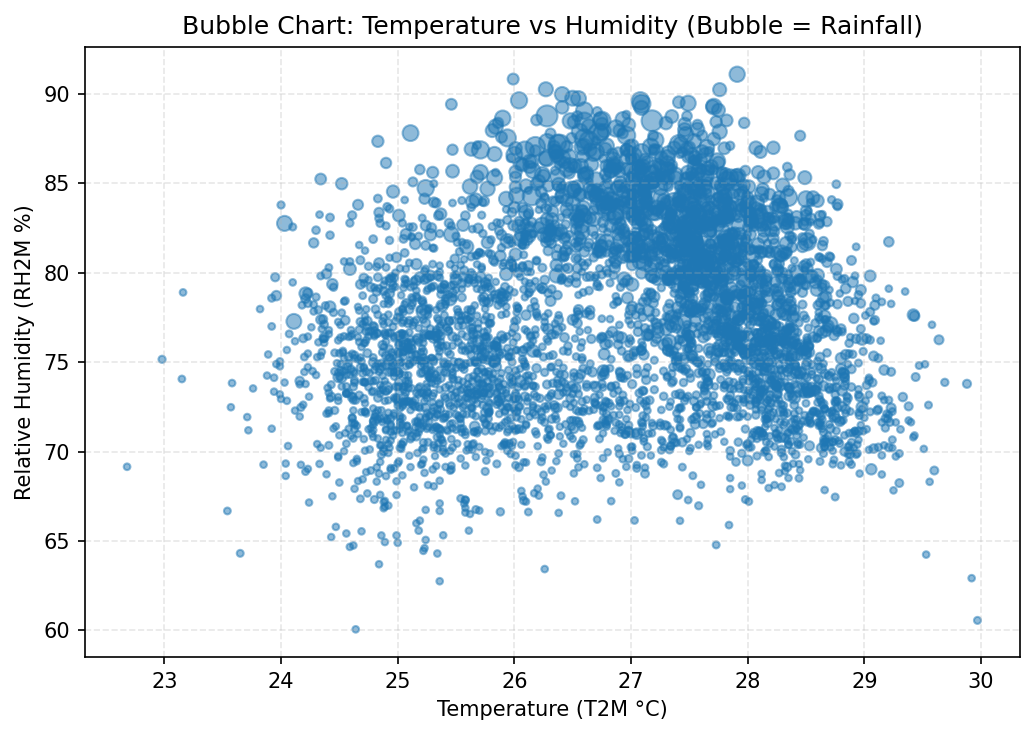

In [32]:
plt.figure(figsize=(7,5), dpi=150)

# Scale bubble size (important: rainfall can be highly skewed)
sizes = np.sqrt(df["PRECTOTCORR"] + 1) * 10  # sqrt reduces extreme dominance

plt.scatter(
    df["T2M"],          # X-axis: Temperature
    df["RH2M"],         # Y-axis: Humidity
    s=sizes,            # Bubble size: Rainfall
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M °C)")
plt.ylabel("Relative Humidity (RH2M %)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

#### Bubble Chart Analysis: Temperature, Humidity and Rainfall

The bubble chart highlights a structured interaction between **temperature, humidity, and precipitation**, reinforcing that rainfall is closely tied to atmospheric moisture conditions.

- A generally **weak nonlinear relationship** is visible between temperature and humidity, with most observations concentrated under **persistently warm (25–29°C) and humid (70–87%)** conditions.

- Larger bubbles (higher rainfall amounts) tend to cluster in **higher-humidity zones (≈80–88%)**, particularly around **26.5–28°C**, indicating precipitation events are associated with moist atmospheric conditions.

- Smaller bubbles dominate the lower-humidity portions of the plot (≈68–75%), suggesting reduced rainfall occurrence under relatively drier conditions.

- The concentration of larger bubbles around a specific warm–humid regime suggests rainfall events are **not randomly distributed**, but occur preferentially under favorable moisture conditions.

- Bubble sizes appear less associated with temperature extremes than with humidity levels, reinforcing that **humidity has stronger explanatory power for precipitation variability than temperature alone.**

### 📌 Conclusion

- Rainfall is strongly associated with **high-moisture atmospheric conditions**, with larger precipitation events concentrated where humidity is elevated.
- Wetter conditions tend to occur within **moderately warm and humid regimes**, rather than at temperature extremes.
- **Humidity appears to be a stronger driver of rainfall occurrence than temperature alone.**
- The chart reinforces earlier findings that **moisture dynamics are a major driver of climate variability**, with precipitation closely linked to humid atmospheric regimes.